# Evaluation Metrics for the created Models

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, PrecisionRecallDisplay
)
from catboost import CatBoostClassifier

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")


### Training the Winning Model (CatBoost)

In [4]:
df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')
df.columns = df.columns.str.lower()

df = df.drop(columns=['customer_id', 'surname'], errors='ignore')

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20, 
    stratify=y,
    random_state=RANDOM_STATE
)

best_model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

### Statstical Metrics like: Precision, Recall, and F1-Score

In [5]:
print("Complete Statistical Evaluation (CatBoost) Scores")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob[:, 1]):.4f}")

print("\nDetailed Breakdown Matrix:")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))


Complete Statistical Evaluation (CatBoost) Scores
Accuracy:  0.8700
Precision: 0.7905
Recall:    0.4914
F1:        0.6061
ROC-AUC:   0.8622

Detailed Breakdown Matrix:
              precision    recall  f1-score   support

Retained (0)       0.88      0.97      0.92      1593
 Churned (1)       0.79      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



### Confusion Matrix & Precision-Recall Curve

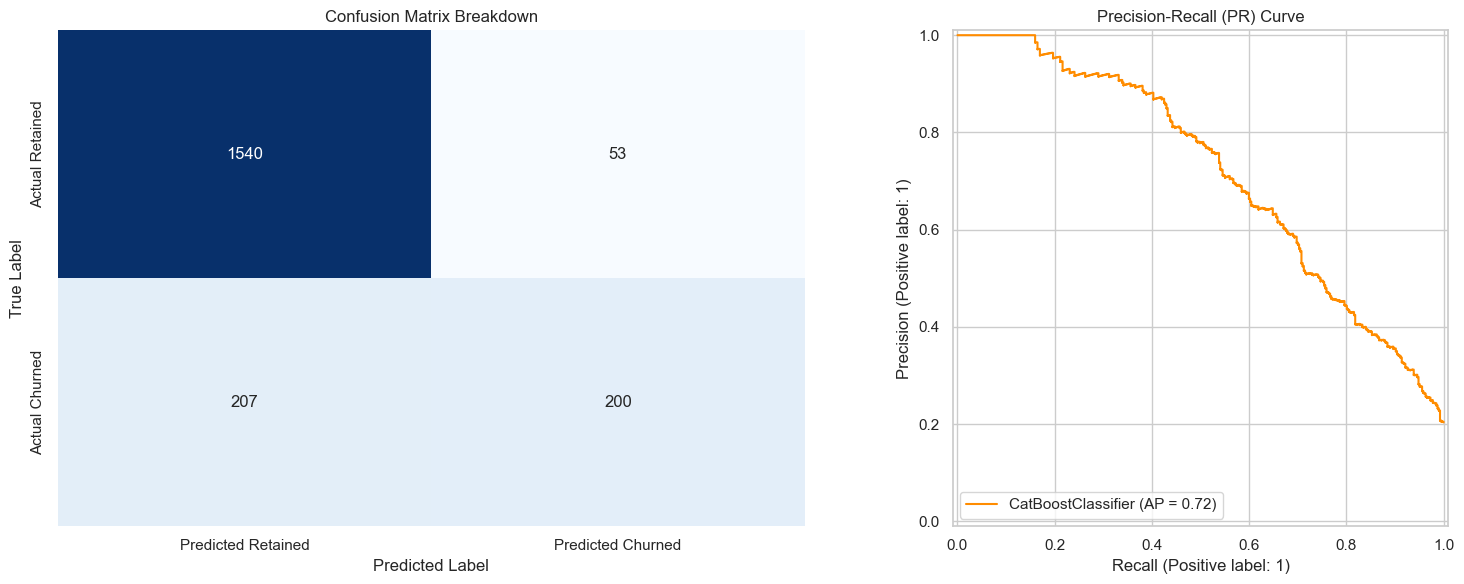

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
axes[0].set_title('Confusion Matrix Breakdown')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Precision-Recall (PR) Curve
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1], color="darkorange")
axes[1].set_title('Precision-Recall (PR) Curve')

plt.tight_layout()
plt.show()


### Business Performance - Lift Curve & Cumulative Gains

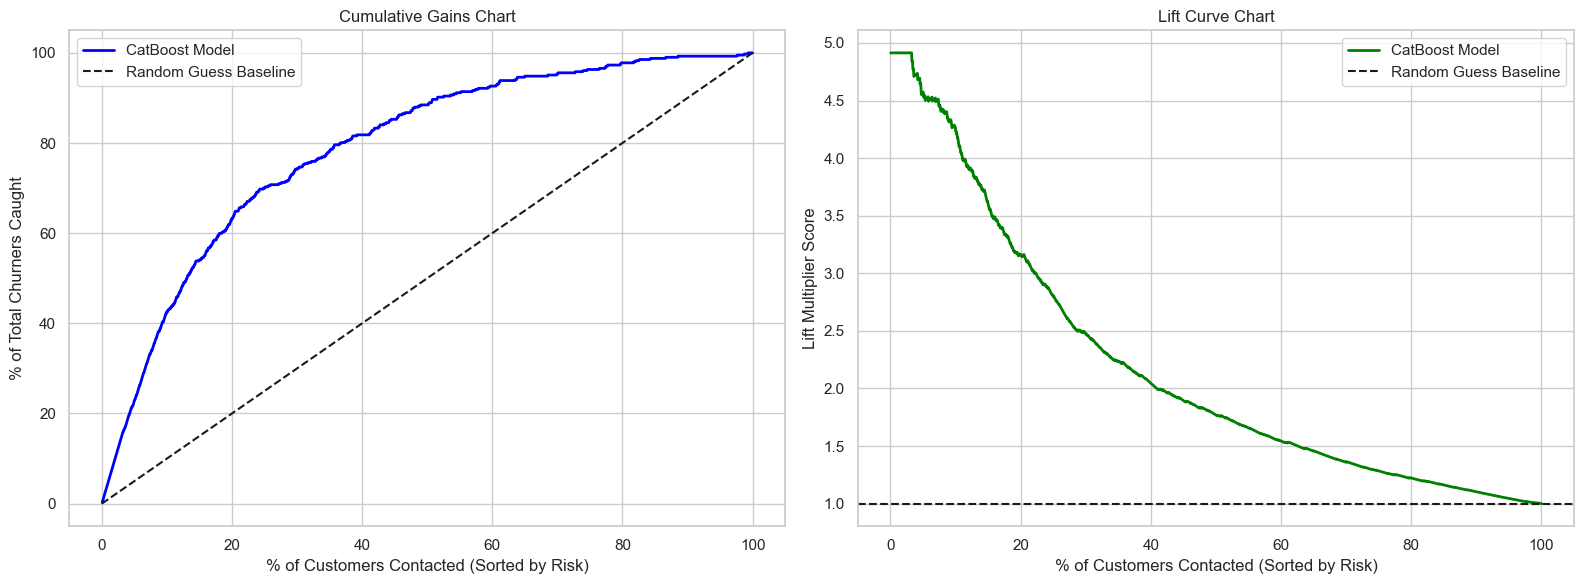

In [7]:
probabilities = y_prob[:, 1]
indices = np.argsort(probabilities)[::-1]
y_test_sorted = y_test.iloc[indices].values

total_positives = np.sum(y_test)
cumulative_positives = np.cumsum(y_test_sorted)
gains = (cumulative_positives / total_positives) * 100
percentages = np.arange(1, len(y_test) + 1) / len(y_test) * 100

baseline_rate = total_positives / len(y_test)
cumulative_rate = cumulative_positives / np.arange(1, len(y_test) + 1)
lift = cumulative_rate / baseline_rate

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative Gains
axes[0].plot(percentages, gains, label='CatBoost Model', color='blue', lw=2)
axes[0].plot([0, 100], [0, 100], 'k--', label='Random Guess Baseline')
axes[0].set_title('Cumulative Gains Chart')
axes[0].set_xlabel('% of Customers Contacted (Sorted by Risk)')
axes[0].set_ylabel('% of Total Churners Caught')
axes[0].legend()

# Lift Curve
axes[1].plot(percentages, lift, label='CatBoost Model', color='green', lw=2)
axes[1].axhline(y=1, color='k', linestyle='--', label='Random Guess Baseline')
axes[1].set_title('Lift Curve Chart')
axes[1].set_xlabel('% of Customers Contacted (Sorted by Risk)')
axes[1].set_ylabel('Lift Multiplier Score')
axes[1].legend()

plt.tight_layout()
plt.show()


### Extra Code cells 
#### I added them because the recall was too low in the next notebook when looking at the results of model tuning. So here I adjusted and recalculated the predictions. Then just visualised the two side-by-side.

In [9]:
custom_threshold = 0.30

y_pred_high_recall = (y_prob[:, 1] >= custom_threshold).astype(int)

print(f"Optimized evaluation scores: threshold = {custom_threshold}")
print(f"New Accuracy: {accuracy_score(y_test, y_pred_high_recall):.4f}")
print(f"New Prcision: {precision_score(y_test, y_pred_high_recall):.4f}")
print(f"New Recall: {recall_score(y_test, y_pred_high_recall):.4f}")
print(f"New F1-Score: {f1_score(y_test, y_pred_high_recall):.4f}")

print(f"\nOptimized Detailed Breakdown Matrix: \n {classification_report(y_test, y_pred_high_recall, target_names=['Retained (0)', 'Churned (1)'])}")

Optimized evaluation scores: threshold = 0.3
New Accuracy: 0.8435
New Prcision: 0.6035
New Recall: 0.6732
New F1-Score: 0.6365

Optimized Detailed Breakdown Matrix: 
               precision    recall  f1-score   support

Retained (0)       0.91      0.89      0.90      1593
 Churned (1)       0.60      0.67      0.64       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000



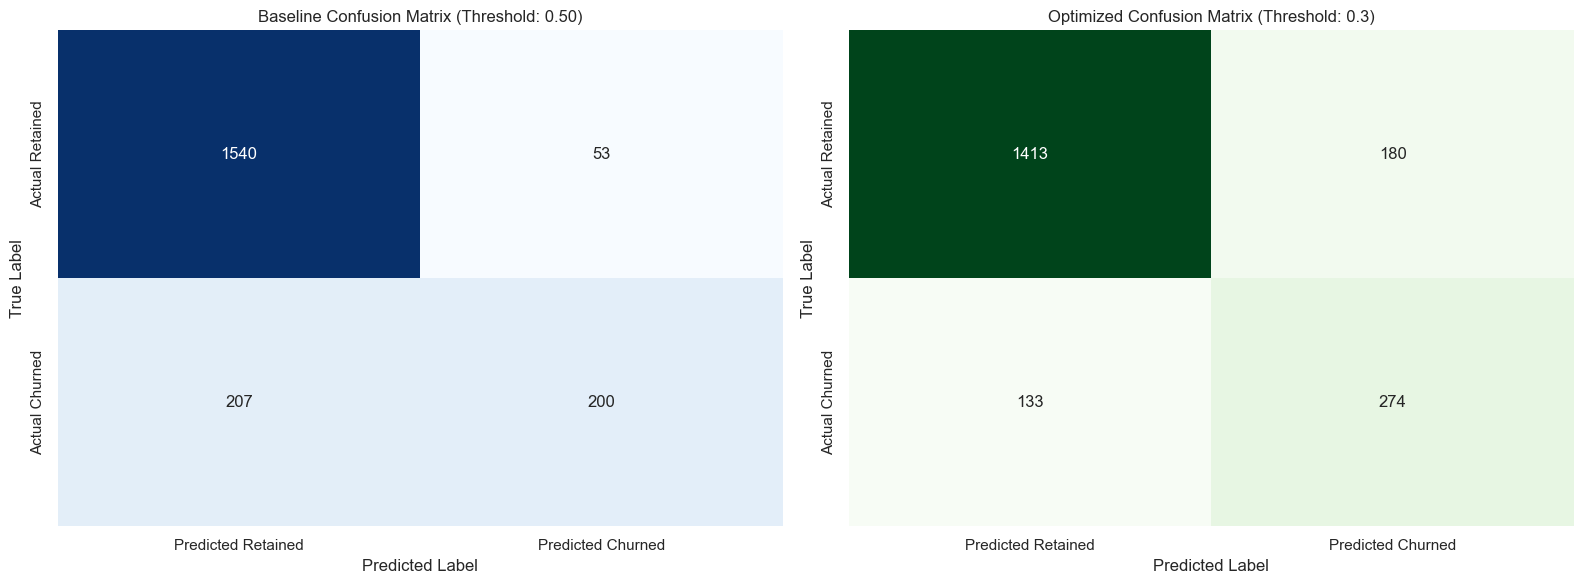

In [10]:
# === Cell 7: Confusion Matrix Comparison ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Baseline Confusion Matrix (Threshold = 0.50)
cm_baseline = confusion_matrix(y_test, y_pred) # Uses old y_pred
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
axes[0].set_title('Baseline Confusion Matrix (Threshold: 0.50)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. Optimized Confusion Matrix (Threshold = 0.30)
cm_optimized = confusion_matrix(y_test, y_pred_high_recall) # Uses new variable
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
axes[1].set_title(f'Optimized Confusion Matrix (Threshold: {custom_threshold})')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


Findings: By lowering the threshold down to 30%, I found that it helped reduce the amount of customers that were about to churn from catching only 200 before, now the model is able to catch 274, as lowering the threshold made it more sensitive (suspicious).